In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df= pd.read_csv('afl_comb_CLdata.csv')

In [50]:
df.head()

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,Abbott,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,"['Geelong Cats', 'St Kilda Saints']"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,Ablett,1984-05-14,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,https://afltables.com/afl/stats/players/G/Gary...,"['Geelong Cats', 'Gold Coast Suns']"


In [51]:
df['player_name']=df['player_name'].str.strip()

In [52]:
df['player_name']

,player_name
0,Ryan Abbott
1,Ryan Abbott
2,Ryan Abbott
3,Ryan Abbott
4,Gary Ablett
...,...
25196,Brad Scott
25197,Brad Scott
25198,Brad Scott
25199,Brad Scott


In [53]:
df.dtypes

,0
player_id,int64
year,int64
team,object
is_finals,bool
games_played,int64
...,...
last_age,float64
height,float64
weight,float64
player_link,object


In [54]:
corr= df.corr(numeric_only=True)
display(corr)

,player_id,year,is_finals,games_played,kicks,marks,handballs,disposals,goals,behinds,...,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played,decade,disposal_efficiency,debut_age,last_age,height,weight
player_id,1.000000,-0.582430,0.021315,0.024669,0.029458,0.000392,-0.059397,-0.008820,0.117961,0.133133,...,0.271710,0.070449,-0.087347,-0.025387,-0.553242,0.153923,-0.076121,0.096122,-0.092275,0.059681
year,-0.582430,1.000000,-0.026696,-0.020019,-0.010425,0.015502,0.075665,0.027459,-0.126340,-0.144144,...,-0.022863,-0.098489,0.126042,0.019554,0.959166,-0.156254,0.096724,-0.222815,0.106219,-0.132917
is_finals,0.021315,-0.026696,1.000000,-0.610329,-0.473155,-0.487248,-0.441529,-0.479889,-0.259839,-0.287497,...,-0.031777,0.008134,0.081645,0.092533,-0.026913,0.063124,-0.029870,0.169879,-0.014380,0.026601
games_played,0.024669,-0.020019,-0.610329,1.000000,0.888725,0.878821,0.807104,0.891477,0.503028,0.548728,...,0.252706,0.135783,0.352317,0.299427,-0.023963,0.031181,-0.059672,0.206117,-0.040286,0.007410
kicks,0.029458,-0.010425,-0.473155,0.888725,1.000000,0.876380,0.831335,0.968881,0.444619,0.513718,...,0.278537,0.134002,0.557299,0.335216,-0.016819,0.135275,-0.108577,0.278309,-0.145478,-0.084523
marks,0.000392,0.015502,-0.487248,0.878821,0.876380,1.000000,0.714958,0.843047,0.520414,0.545837,...,0.236114,0.192500,0.470607,0.382276,0.002517,0.127516,-0.078525,0.254581,0.053030,0.086976
handballs,-0.059397,0.075665,-0.441529,0.807104,0.831335,0.714958,1.000000,0.943033,0.259540,0.330312,...,0.236371,0.000847,0.550629,0.255228,0.058816,-0.230319,-0.086801,0.230955,-0.129594,-0.086204
disposals,-0.008820,0.027459,-0.479889,0.891477,0.968881,0.843047,0.943033,1.000000,0.382178,0.455259,...,0.271251,0.080594,0.578850,0.312829,0.016127,-0.021611,-0.103710,0.269596,-0.144865,-0.089015
goals,0.117961,-0.126340,-0.259839,0.503028,0.444619,0.520414,0.259540,0.382178,1.000000,0.896612,...,0.371317,0.734780,0.272062,0.218188,-0.123312,0.232364,-0.107737,0.214228,0.000901,0.108103
behinds,0.133133,-0.144144,-0.287497,0.548728,0.513718,0.545837,0.330312,0.455259,0.896612,1.000000,...,0.386556,0.648297,0.304451,0.216829,-0.140941,0.224508,-0.125022,0.214159,-0.031516,0.077960


<Axes: title={'center': 'Games played by Teams'}, xlabel='team', ylabel='games_played'>

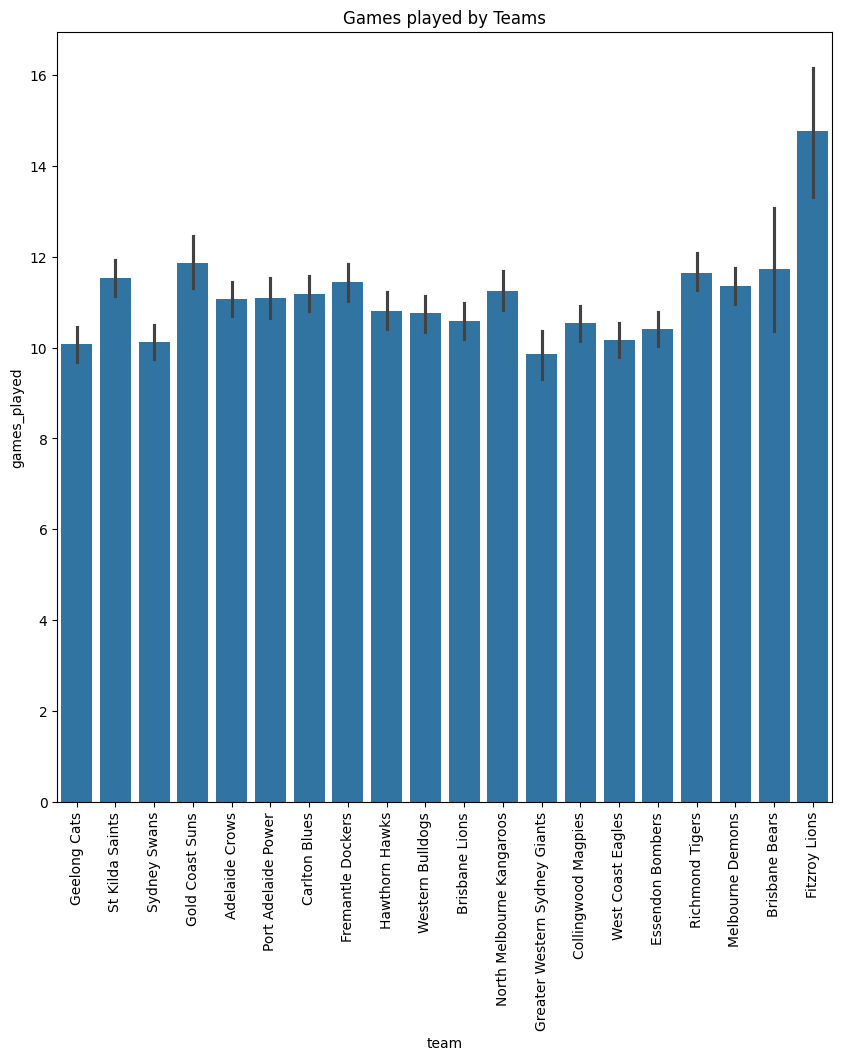

In [55]:
plt.figure(figsize=(10,10))
plt.title('Games played by Teams')
plt.xticks(rotation=90)
sns.barplot(x=df['team'],y=df['games_played'])

In [56]:
df.groupby('team')['games_played'].count().sort_values(ascending=False)

,games_played
team,
Geelong Cats,1677
West Coast Eagles,1631
Sydney Swans,1599
Essendon Bombers,1585
Collingwood Magpies,1564
Western Bulldogs,1498
Adelaide Crows,1468
North Melbourne Kangaroos,1462
Hawthorn Hawks,1446


Those black vertical lines are error bars are telling that: teams with wide error bars have much less consistent/less data behind their average than teams with narrow ones, Fitzroy Lions shows the highest average games played by a clear margin, with the widest error bar of any team. That combination (highest value + most uncertainty) is a classic sign of a small sample size skewing the average

Fitzroy Lions and Brisbane Bears are both historical AFL teams that no longer exist (Fitzroy merged into the Brisbane Lions in 1996; Brisbane Bears also became part of that merger) — they have far fewer seasons of data than currently-active teams, so their average is being computed from a much smaller, less representative sample

player_name
Tony Lockett          1360.0
Lance Franklin        1066.0
Matthew Lloyd          926.0
Josh Kennedy           880.0
Matthew Richardson     800.0
Tom Hawkins            796.0
Jack Riewoldt          787.0
Saverio Rocca          748.0
Barry Hall             746.0
Jeremy Cameron         736.0
Name: goals, dtype: float64


<Axes: title={'center': 'Top 10 AFL Players by Career Goals'}, xlabel='Goals', ylabel='Player'>

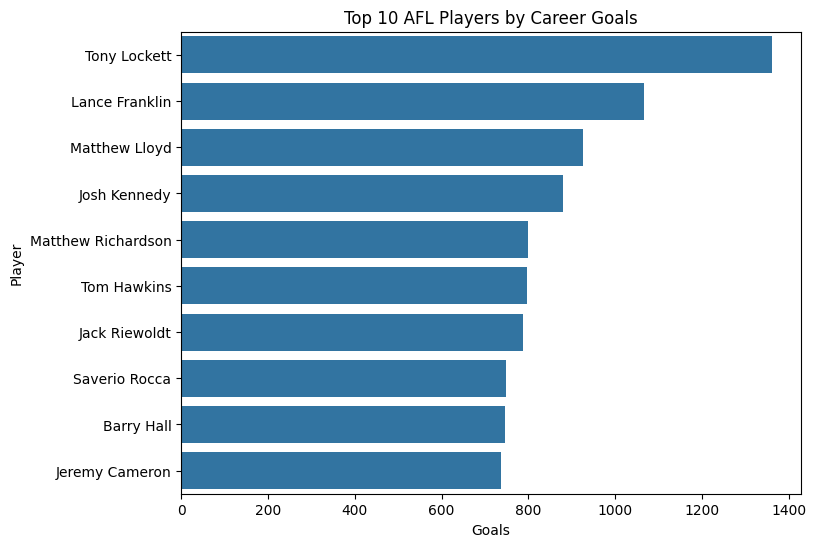

In [60]:
top10_players=df.groupby('player_name')['goals'].sum().sort_values(ascending=False).head(10)
print(top10_players)
plt.figure(figsize=(8,6))
plt.title('Top 10 AFL Players by Career Goals')
plt.ylabel('Player')
plt.xlabel('Goals')
# plt.xticks(rotation=90)
sns.barplot(x=top10_players,y=top10_players.index)

This above Barplot tells about top 10 players who scored most goals.

Tony Lockett leads all players in total career goals by a clear margin over Lance Franklin in second place; this reflects total career output and may favor players with longer careers over those with a higher scoring rate per game

<Axes: title={'center': 'Kicks in Finals'}, xlabel='Finals Match', ylabel='Number of Kicks'>

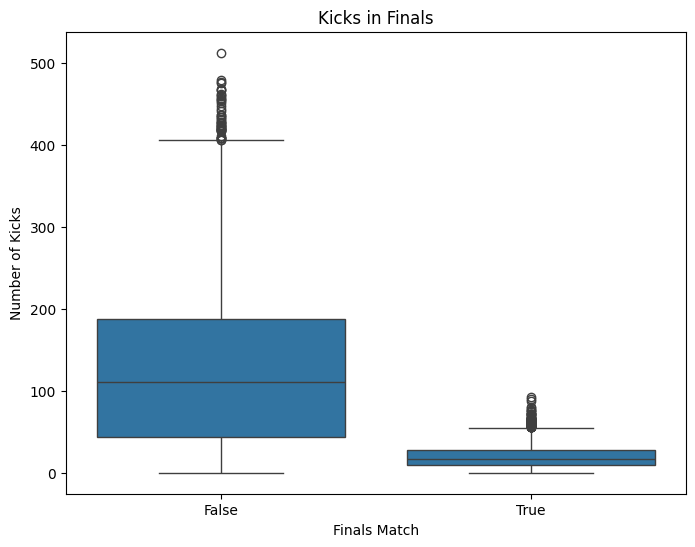

In [63]:
plt.figure(figsize=(8,6))
plt.title('Kicks in Finals')
plt.ylabel('Number of Kicks')
plt.xlabel('Finals Match')
# plt.xticks(rotation=90)
sns.boxplot(x='is_finals',y='kicks', data=df)

this boxplot shows that Players generally record different distributions of kicks in finals compared with regular-season matches

In [64]:
print(df["is_finals"].value_counts())

is_finals
False    19379
True      5822
Name: count, dtype: int64


In [67]:
df[["games_played", "kicks"]].head(10)

,games_played,kicks
0,3,17.0
1,1,3.0
2,1,5.0
3,1,2.0
4,12,37.0
5,22,189.0
6,18,148.0
7,3,30.0
8,22,236.0
9,2,21.0


<Axes: title={'center': 'Kicks in Finals'}, xlabel='Matche Category', ylabel='Kicks per Game'>

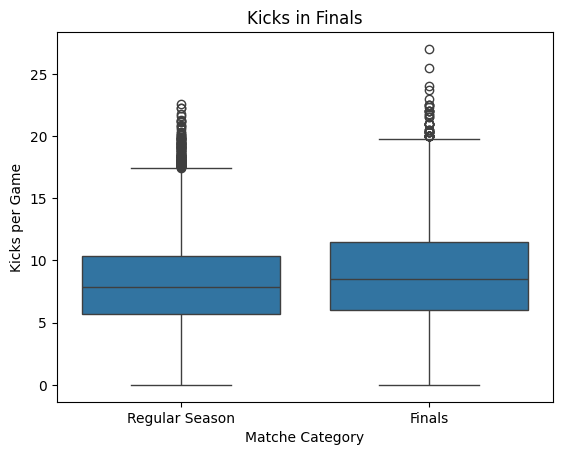

In [74]:
df["kicks_per_game"]=df["kicks_per_game"] = df["kicks"] / df["games_played"]
plt.title('Kicks in Finals')
plt.xticks([0, 1], ["Regular Season", "Finals"])
plt.ylabel('Kicks per Game')
plt.xlabel('Matche Category')
sns.boxplot(data=df, x="is_finals", y="kicks_per_game")

Kicks per game are similar across match types, although finals show a slightly higher median and several high-performing outliers

<Axes: title={'center': 'Distribution of Disposals by Match Type'}, xlabel='Disposals', ylabel='Density'>

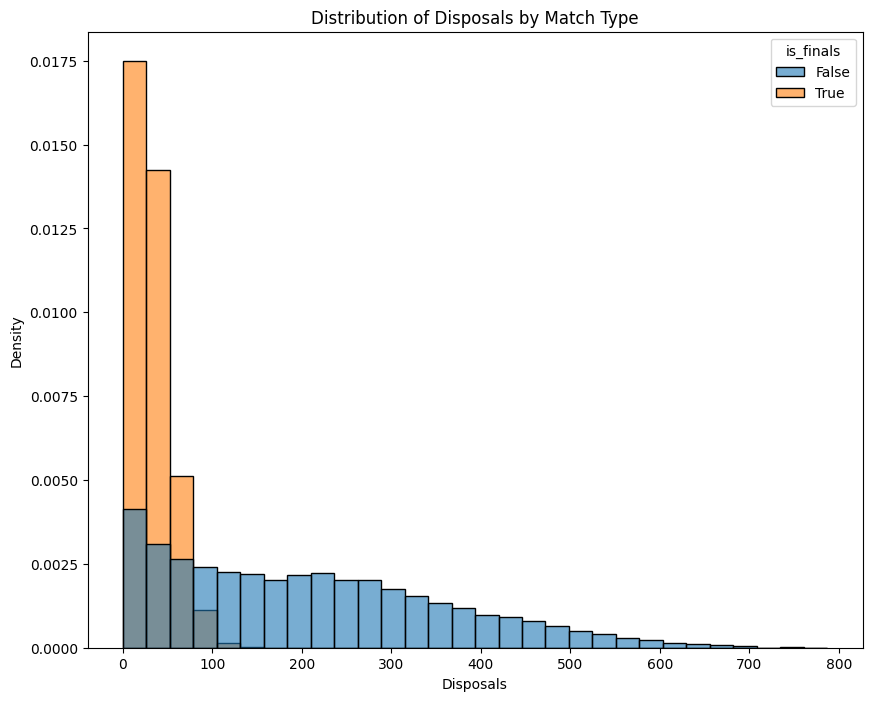

In [89]:
plt.figure(figsize=(10,8))
plt.title('Distribution of Disposals by Match Type')
plt.ylabel('Density')
plt.xlabel('Disposals')
sns.histplot(data=df, x='disposals', hue='is_finals', bins=30,stat="density", common_norm=False ,alpha=0.6)



Most players record relatively low disposal counts, while regular-season matches exhibit a wider spread and more high-disposal performances than finals.

<Axes: title={'center': 'Average Goals per Year'}, xlabel='Year', ylabel='Average Goals'>

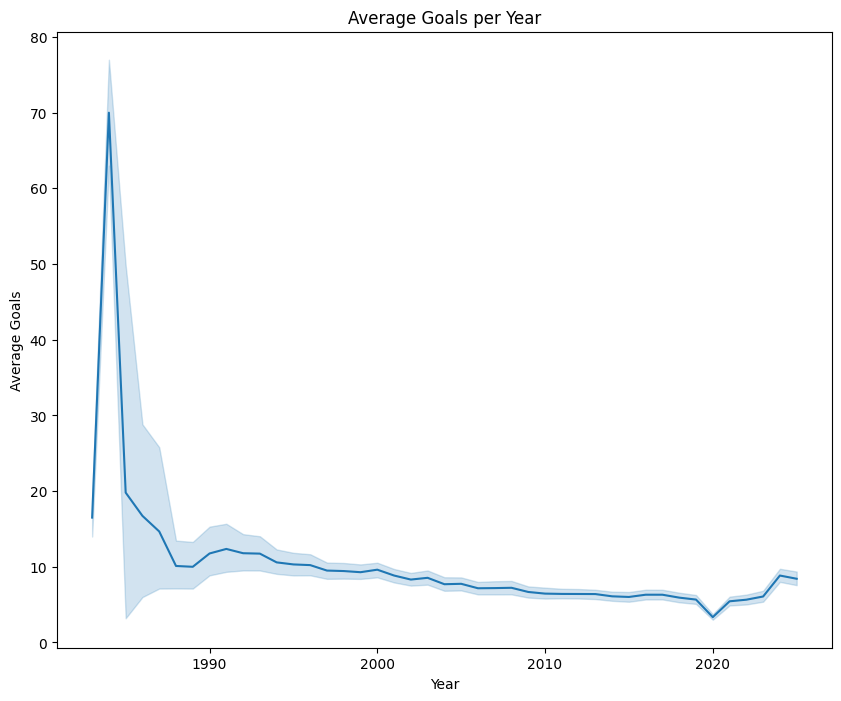

In [100]:


plt.figure(figsize=(10,8))
plt.title('Average Goals per Year')
plt.xlabel('Year')
plt.ylabel('Average Goals')
sns.lineplot(data=df, x='year', y='goals')

This line plot shows the average number of goals through out the years.

The unusually high average in 1984 is due to the dataset containing only two player records for that year, making the average unrepresentative

In [101]:

df.groupby("year")["goals"].agg(["count", "mean", "max"])

,count,mean,max
year,,,
1983,2,16.500000,19.0
1984,2,70.000000,77.0
1985,5,19.800000,79.0
1986,11,16.727273,60.0
1987,24,14.666667,117.0
1988,37,10.108108,37.0
1989,57,10.000000,78.0
1990,83,11.759036,98.0
1991,114,12.359649,118.0


<Axes: xlabel='year', ylabel='avg_goals'>

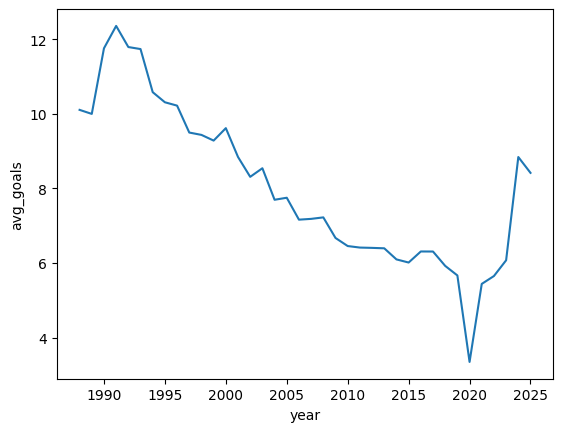

In [102]:
year_stats = df.groupby("year").agg(
    avg_goals=("goals", "mean"),
    count=("goals", "count")
).reset_index()

year_stats = year_stats[year_stats["count"] >= 30]

sns.lineplot(data=year_stats, x="year", y="avg_goals", errorbar=None)

Filtered the years making problem, still problem with 2020 year

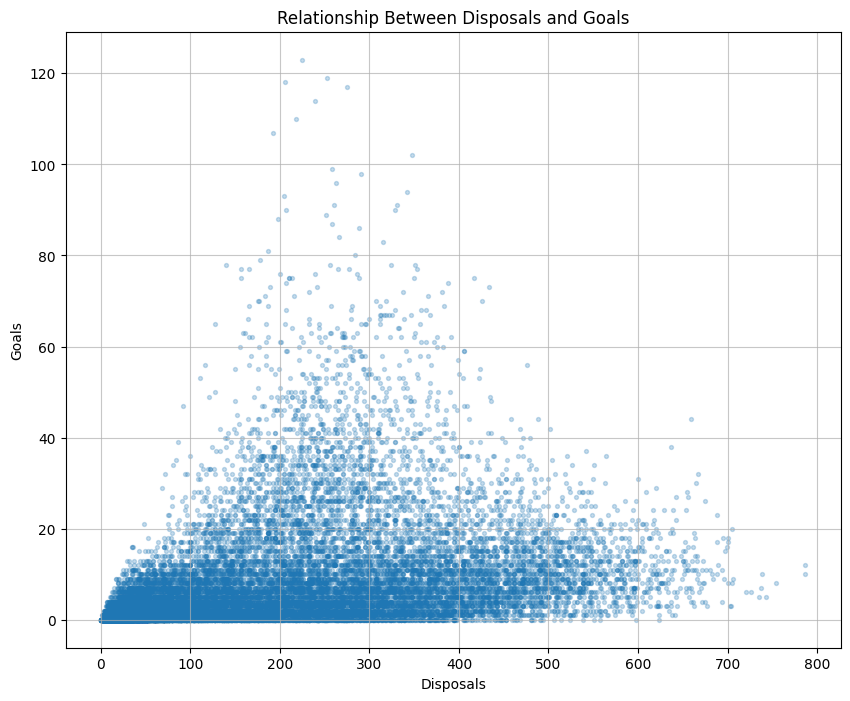

In [127]:
plt.figure(figsize=(10,8))
plt.grid(alpha=0.7)
plt.title("Relationship Between Disposals and Goals")
plt.xlabel("Disposals")
plt.ylabel("Goals")
plt.scatter(df["disposals"],df["goals"],s=8,alpha=0.25)

This scatter plot shows that there is no strong linear relationship between disposals and goals, indicating that players with the most disposals are not necessarily the highest goal scorers


<Axes: >

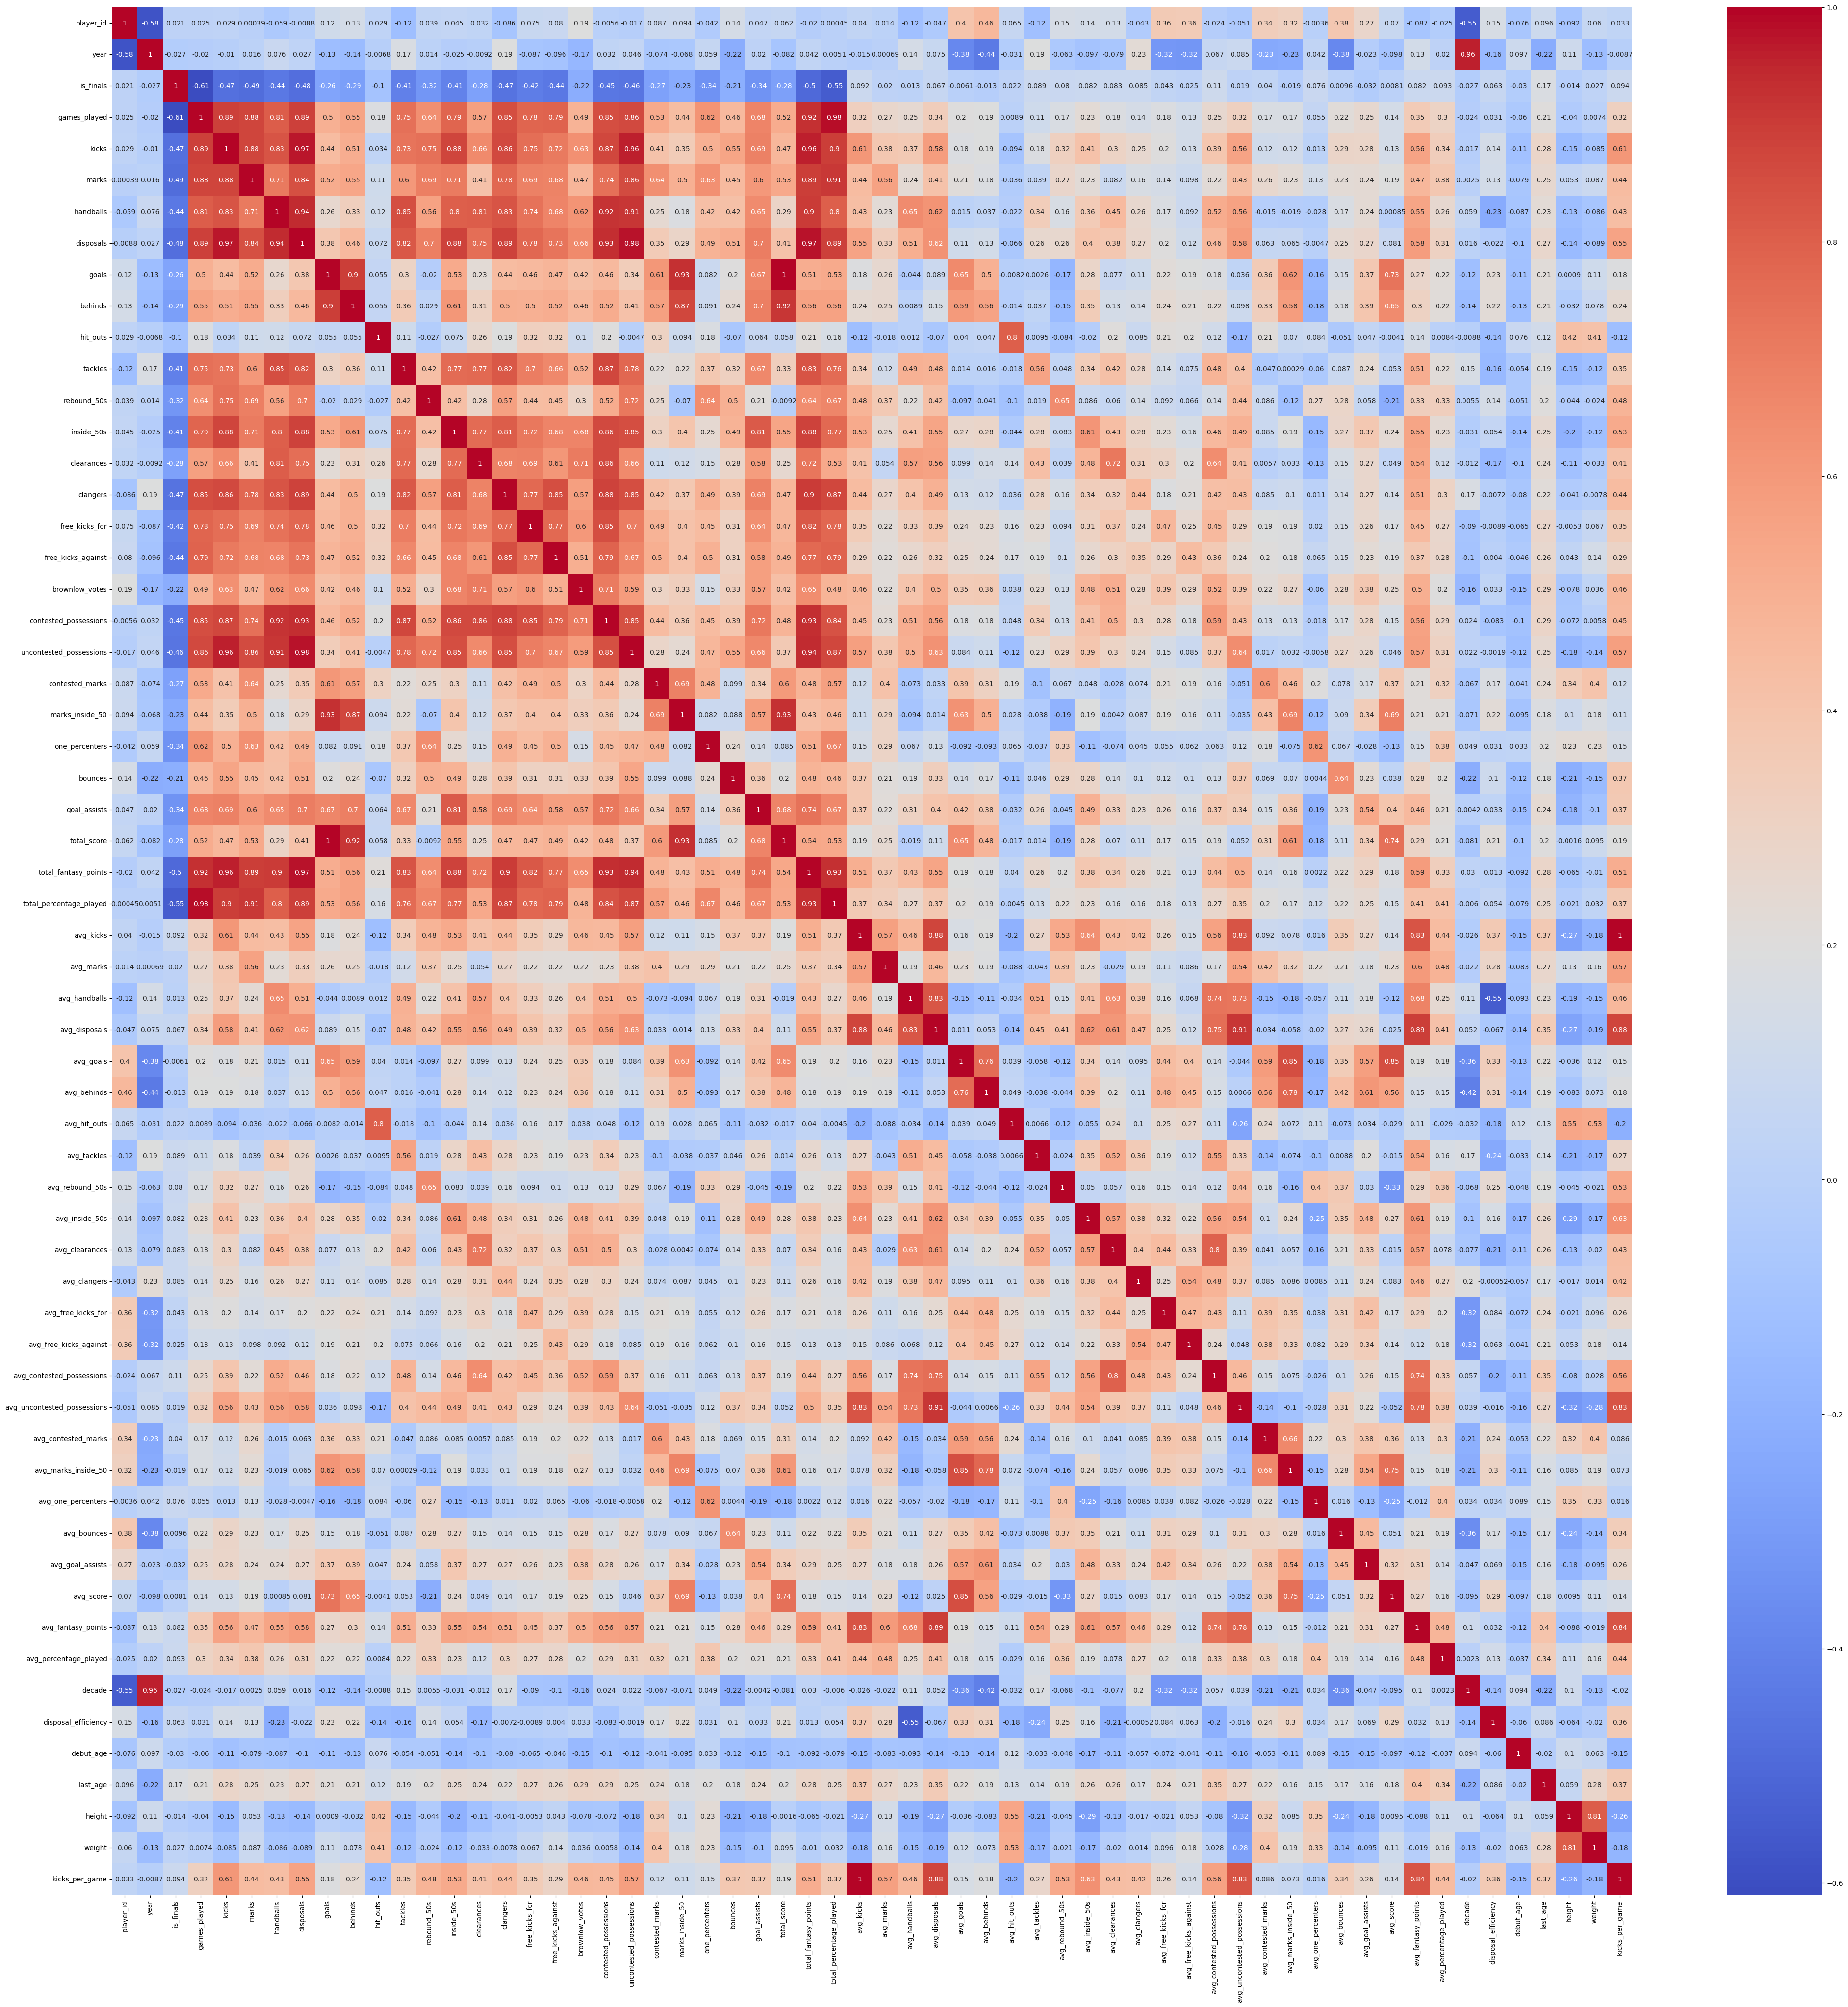

In [131]:
plt.figure(figsize=(50,50))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

The heatmap reveals strong positive correlations among related performance metrics, while most unrelated statistics show weak or no correlation